# Phase 3 — CDML and FiLM: Reproducing the Paper's Core Methods

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## What this notebook does

1. Loads the same data and uses the same `GaitCNN` architecture as Phase 2
2. Implements the **FiLM / Adapt layer** (γₖ, βₖ per task) — the `Adapt` baseline from the paper
3. Implements the **CDML layer** (`m = sₖ ⊙ h`) — the paper's proposed method
4. Runs all three methods (Std, Adapt, CDML) sequentially across 4 tasks
5. Compares accuracy matrices and forgetting curves → reproduces **Fig. 4** and **Table III** of the paper
6. Optionally adds **replay** (10%, 30%) to reproduce the ablation study

## Key ideas

| Method | How it works | Data transmitted |
|---|---|---|
| **Std** | Raw fine-tuning, no protection | Nothing (or % replay) |
| **Adapt (FiLM)** | Per-task scale γₖ and shift βₖ remap features | 16 384 bytes / task |
| **CDML** | Per-task binary sequence sₖ multiplies embedding | 4 bytes / task (seed only) |

---

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Check for Apple Silicon GPU (MPS), then CUDA, then CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using device: MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using device: CUDA (NVIDIA GPU)")
else:
    DEVICE = torch.device("cpu")
    print("Using device: CPU")

Using device: MPS (Apple Silicon GPU)


## 1. Configuration

In [2]:
# ── Paths — same as Phase 2 ───────────────────────────────────────────────────
TRAIN_DATA_DIR = '../Data/Dataset_1/train'
TEST_DATA_DIR  = '../Data/Dataset_1/test'

# ── Data ──────────────────────────────────────────────────────────────────────
N_CHANNELS   = 6
WINDOW_SIZE  = 128
VAL_SPLIT    = 0.15
RANDOM_SEED  = 27

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS      = 50    # 100 for fast runs, 400 to match the paper
BATCH_SIZE  = 64
LR_INIT     = 1e-3
LR_DECAY    = 0.98   # per-epoch exponential decay — matches paper behaviour

# ── CL task split (Table II) ──────────────────────────────────────────────────
TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}
N_CLASSES_TOTAL = 118
EMBED_DIM       = 128   # dimension of the feature embedding h

# ── CDML / Adapt settings ─────────────────────────────────────────────────────
CDML_SEED_BASE = 1000   # seeds for each task: 1000, 1001, 1002, 1003
# Replay fractions to test in ablation (0 = no replay, the main experiment)
REPLAY_FRACTIONS = [0.0, 0.1, 0.3]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading — identical to Phase 2

In [3]:
def load_split(data_dir, prefix):
    """Load a 6-channel IMU split (train or test) from .txt files."""
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)   # (N, 6, 128)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

# ── Normalize from training stats only (no leakage) ───────────────────────────
ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

# ── Label remapping to 0-indexed ──────────────────────────────────────────────
unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])
print(f'Labels remapped: {y_train.min()}–{y_train.max()} → 0–{y_train_idx.max()}')

Train: (33104, 6, 128)   Test: (3740, 6, 128)
Labels remapped: 1–118 → 0–117


In [4]:
def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    """Build per-task {train, val, test} TensorDatasets."""
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t  = torch.tensor(X_tr[mask_tr])
        y_t  = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val   = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)

        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test


## 3. Model architectures

All three methods share the same CNN backbone. The difference is what happens between
the embedding layer `h` and the classifier:

```
Std:    Input → CNN → h ──────────────────── FC → logits
Adapt:  Input → CNN → h → γₖ * h + βₖ  ──── FC → logits
CDML:   Input → CNN → h → h ⊙ sₖ       ──── FC → logits
```

In [5]:
# ── Shared backbone ───────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    """
    Baseline CNN (Zou et al. 2020 / Milani 2024, Fig. 2 gray blocks).
    4 × ConvBlock → Flatten → FC(embed_dim) → FC(n_classes)
    The embed() method exposes h so CDML/Adapt can intercept it.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 128),
            nn.Flatten(),
        )
        dummy     = torch.zeros(1, n_channels, WINDOW_SIZE)
        flat_size = self.feature_extractor(dummy).shape[1]
        self.embedding  = nn.Linear(flat_size, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(self.embed(x))


# Sanity check
_ = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
out = _(torch.zeros(4, N_CHANNELS, WINDOW_SIZE).to(DEVICE))
print(f'GaitCNN output: {out.shape}  params: {sum(p.numel() for p in _.parameters()):,}')

GaitCNN output: torch.Size([4, 118])  params: 227,222


In [6]:
# ── FiLM / Adapt layer ────────────────────────────────────────────────────────
class FiLMLayer(nn.Module):
    """
    Feature-wise Linear Modulation (Perez et al. 2018, used as 'Adapt' in the paper).
    Learns a per-task scale γ and bias β that remap the embedding h:
        m = γₖ ⊙ h + βₖ
    γ and β are SMALL extra parameters (~2 × embed_dim floats) trained per task.
    They are saved and re-loaded at inference time for the correct task.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(embed_dim))   # init: identity scale
        self.beta  = nn.Parameter(torch.zeros(embed_dim))  # init: zero shift

    def forward(self, h):
        return self.gamma * h + self.beta


class GaitCNN_Adapt(nn.Module):
    """
    GaitCNN + FiLM layer inserted between embedding and classifier.
    During training: backbone + current task's FiLM are jointly updated.
    During evaluation on task k: swap in FiLM_k before forwarding.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.backbone = GaitCNN(n_channels, n_classes, embed_dim)
        self.film     = FiLMLayer(embed_dim)   # active FiLM (replaced per task)
        # Store each task's trained FiLM parameters
        self.film_states = {}  # {task_name: state_dict}

    def forward(self, x):
        h = self.backbone.embed(x)
        m = self.film(h)
        return self.backbone.classifier(m)

    def save_film(self, task_name):
        """Snapshot the current FiLM weights for this task."""
        self.film_states[task_name] = deepcopy(self.film.state_dict())

    def load_film(self, task_name):
        """Restore a previously saved FiLM for evaluation."""
        self.film.load_state_dict(self.film_states[task_name])

    def reset_film(self):
        """Re-initialise FiLM to identity before training a new task."""
        nn.init.ones_(self.film.gamma)
        nn.init.zeros_(self.film.beta)


print('FiLM / Adapt model defined.')
print(f'  FiLM extra params per task: {2 * EMBED_DIM} floats = {2 * EMBED_DIM * 4} bytes')

FiLM / Adapt model defined.
  FiLM extra params per task: 256 floats = 1024 bytes


In [7]:
# ── CDML layer ────────────────────────────────────────────────────────────────
def generate_cdml_sequence(embed_dim, seed):
    """
    Generate a pseudo-random binary sequence sₖ ∈ {-1, +1}^embed_dim.
    The seed (4 bytes) is all that needs to be transmitted — the receiver
    re-generates the full sequence locally.

    The paper evaluates several generators (Table I). We use numpy's default
    Generator (PCG64), which passes the KS and run tests used in the paper.
    """
    rng = np.random.default_rng(seed)
    raw = rng.random(embed_dim)          # uniform [0, 1)
    seq = np.where(raw >= 0.5, 1.0, -1.0).astype(np.float32)  # quantise to ±1
    return torch.tensor(seq)             # shape: (embed_dim,)


class CDMLLayer(nn.Module):
    """
    Code Division Modulation Layer (Milani 2024, Eq. 1).
    m = sₖ ⊙ h  (element-wise product of embedding with binary sequence)

    sₖ is NOT a learnable parameter — it is derived from a seed.
    The seed (4 bytes) is transmitted via secure channel.
    An attacker without the seed sees a scrambled feature space -> MIA fails.
    """
    def __init__(self, embed_dim, seed):
        super().__init__()
        seq = generate_cdml_sequence(embed_dim, seed)
        # Register as a buffer (not a parameter — not updated by the optimizer)
        self.register_buffer('sequence', seq)

    def forward(self, h):
        return h * self.sequence   # broadcast over batch dimension


class GaitCNN_CDML(nn.Module):
    """
    GaitCNN + CDML layer inserted between embedding and classifier.
    The modulating sequence changes per task (different seed).
    At inference for task k: load sequence sₖ before forwarding.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)  # active sequence
        self.seeds     = {}   # {task_name: seed} — transmitted via secure channel

    def forward(self, x):
        h = self.backbone.embed(x)
        m = self.cdml(h)
        return self.backbone.classifier(m)

    def set_task_sequence(self, task_name, seed):
        """Switch to the sequence for task k (given its seed)."""
        self.seeds[task_name] = seed
        seq = generate_cdml_sequence(self.embed_dim, seed).to(
            next(self.parameters()).device)
        self.cdml.sequence = seq


# Verify CDML properties: orthogonality and balance
seqs = [generate_cdml_sequence(EMBED_DIM, CDML_SEED_BASE + k) for k in range(4)]
print('CDML sequence diagnostics:')
for k in range(4):
    s = seqs[k]
    balance = s.mean().item()
    print(f'  Task {k+1} seed={CDML_SEED_BASE+k}: '
          f'balance={balance:.3f} (ideally 0)  '
          f'values={s.unique().tolist()}')
print('Cross-task cosine similarities (should be ≈ 0):')
for i in range(4):
    for j in range(i+1, 4):
        cs = (seqs[i] @ seqs[j] / EMBED_DIM).item()
        print(f'  s{i+1}·s{j+1} = {cs:.4f}')

CDML sequence diagnostics:
  Task 1 seed=1000: balance=-0.062 (ideally 0)  values=[-1.0, 1.0]
  Task 2 seed=1001: balance=-0.219 (ideally 0)  values=[-1.0, 1.0]
  Task 3 seed=1002: balance=-0.203 (ideally 0)  values=[-1.0, 1.0]
  Task 4 seed=1003: balance=-0.031 (ideally 0)  values=[-1.0, 1.0]
Cross-task cosine similarities (should be ≈ 0):
  s1·s2 = 0.0312
  s1·s3 = 0.1094
  s1·s4 = -0.0625
  s2·s3 = -0.0469
  s2·s4 = 0.0312
  s3·s4 = 0.0156


## 4. Training utilities

Shared helpers for all three methods, plus a replay buffer.

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct    += (model(X_b).argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model(X_b)
        total_loss += criterion(logits, y_b).item() * len(y_b)
        correct    += (logits.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


def build_replay_loader(past_task_data, replay_fraction, batch_size, current_train_ds):
    """
    Build a DataLoader that mixes the current task's training data with
    a random fraction of each previous task's training data (replay).
    replay_fraction=0.0 → returns only current task data (standard fine-tuning).
    """
    if replay_fraction == 0.0 or len(past_task_data) == 0:
        return DataLoader(current_train_ds, batch_size=batch_size, shuffle=True)

    datasets = [current_train_ds]
    for past_ds in past_task_data:
        n_replay = max(1, int(len(past_ds) * replay_fraction))
        indices  = torch.randperm(len(past_ds))[:n_replay].tolist()
        subset   = torch.utils.data.Subset(past_ds, indices)
        datasets.append(subset)
    combined = ConcatDataset(datasets)
    return DataLoader(combined, batch_size=batch_size, shuffle=True)


def run_sequential_training(model, task_data, task_names, method_name,
                             epochs, lr_init, lr_decay, batch_size,
                             device, replay_fraction=0.0,
                             adapt_film_only=False, verbose_every=10):
    """
    Core sequential training loop — works for Std, Adapt, and CDML.

    Parameters
    ----------
    adapt_film_only : bool
        If True (Adapt method): freeze the backbone and only update FiLM
        parameters during tasks 2–4. For task 1, full model is trained.
    """
    n_tasks    = len(task_names)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    all_history = {}
    criterion   = nn.CrossEntropyLoss()
    past_train_datasets = []

    for step_idx, task_name in enumerate(task_names):
        print(f'\n{"-"*52}')
        print(f'[{method_name}] Step {step_idx+1}: {task_name}')
        print(f'{"-"*52}')

        # ── CDML: switch to this task's modulating sequence ───────────────────
        if hasattr(model, 'set_task_sequence'):
            seed = CDML_SEED_BASE + step_idx
            model.set_task_sequence(task_name, seed)
            print(f'  CDML sequence seed: {seed}')

        # ── Adapt: reset FiLM to identity before each new task ────────────────
        if hasattr(model, 'reset_film'):
            model.reset_film()

        # ── Decide which parameters to optimize ───────────────────────────────
        if adapt_film_only and step_idx > 0 and hasattr(model, 'film'):
            # Freeze backbone; only learn FiLM for tasks 2+
            params_to_train = model.film.parameters()
        else:
            params_to_train = model.parameters()

        optimizer = optim.Adam(params_to_train, lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        # ── Build DataLoader (with optional replay) ───────────────────────────
        train_loader = build_replay_loader(
            past_train_datasets, replay_fraction,
            batch_size, task_data[task_name]['train']
        )
        val_loader = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size, shuffle=False)

        # ── Epoch loop ────────────────────────────────────────────────────────
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        for epoch in range(1, epochs + 1):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
            scheduler.step()
            history['train_loss'].append(tr_loss)
            history['train_acc'].append(tr_acc)
            history['val_loss'].append(vl_loss)
            history['val_acc'].append(vl_acc)
            if epoch % verbose_every == 0 or epoch == 1:
                print(f'  Epoch {epoch:>3}/{epochs}  '
                      f'train {tr_acc:.3f}  val {vl_acc:.3f}  '
                      f'lr {scheduler.get_last_lr()[0]:.2e}')

        all_history[task_name] = history

        # ── Save FiLM state for this task (Adapt only) ────────────────────────
        if hasattr(model, 'save_film'):
            model.save_film(task_name)

        # ── Evaluate on all tasks seen so far ─────────────────────────────────
        print(f'\n  Evaluation after {task_name}:')
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            # For Adapt: restore the correct FiLM for this eval task
            if hasattr(model, 'load_film'):
                model.load_film(eval_task)
            # For CDML: restore the correct sequence for this eval task
            if hasattr(model, 'set_task_sequence'):
                model.set_task_sequence(eval_task, model.seeds[eval_task])

            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            _, acc = evaluate(model, test_loader, criterion, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'    {eval_task}: {acc*100:.1f}%')

        # ── Store past training data for replay ───────────────────────────────
        past_train_datasets.append(task_data[task_name]['train'])

    print(f'\n[{method_name}] Sequential training complete.')
    return acc_matrix, all_history


print('Training utilities defined.')

Training utilities defined.


## 5. Run all three methods

This is the main experiment — takes a while at 100 epochs × 3 methods × 4 tasks.  
Reduce `EPOCHS` to 20 for a fast smoke-test first.

In [9]:
task_names = list(TASK_SPLITS.keys())
results    = {}   # {method_name: acc_matrix}
histories  = {}   # {method_name: history dict}

# ── 1. Standard fine-tuning (Std, 0% replay) ─────────────────────────────────
model_std = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
results['Std'], histories['Std'] = run_sequential_training(
    model_std, task_data, task_names, 'Std',
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, DEVICE,
    replay_fraction=0.0
)

# ── 2. FiLM / Adapt (10% replay as in paper's main Adapt result) ──────────────
model_adapt = GaitCNN_Adapt(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
results['Adapt'], histories['Adapt'] = run_sequential_training(
    model_adapt, task_data, task_names, 'Adapt',
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, DEVICE,
    replay_fraction=0.1,
    adapt_film_only=True
)

# ── 3. CDML (0% replay — paper's main result) ─────────────────────────────────
model_cdml = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                           seed=CDML_SEED_BASE).to(DEVICE)
results['CDML'], histories['CDML'] = run_sequential_training(
    model_cdml, task_data, task_names, 'CDML',
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, DEVICE,
    replay_fraction=0.0
)

print('\nAll methods complete.')


----------------------------------------------------
[Std] Step 1: Task 1
----------------------------------------------------
  Epoch   1/50  train 0.642  val 0.931  lr 9.80e-04
  Epoch  10/50  train 0.999  val 0.983  lr 8.17e-04
  Epoch  20/50  train 1.000  val 0.985  lr 6.68e-04
  Epoch  30/50  train 1.000  val 0.986  lr 5.45e-04
  Epoch  40/50  train 1.000  val 0.986  lr 4.46e-04
  Epoch  50/50  train 1.000  val 0.986  lr 3.64e-04

  Evaluation after Task 1:
    Task 1: 90.2%

----------------------------------------------------
[Std] Step 2: Task 2
----------------------------------------------------
  Epoch   1/50  train 0.770  val 0.943  lr 9.80e-04
  Epoch  10/50  train 0.998  val 0.987  lr 8.17e-04
  Epoch  20/50  train 0.999  val 0.984  lr 6.68e-04
  Epoch  30/50  train 1.000  val 0.989  lr 5.45e-04
  Epoch  40/50  train 1.000  val 0.988  lr 4.46e-04
  Epoch  50/50  train 1.000  val 0.988  lr 3.64e-04

  Evaluation after Task 2:
    Task 1: 0.0%
    Task 2: 93.9%

----------

## 6. Compare accuracy matrices — reproducing Fig. 4

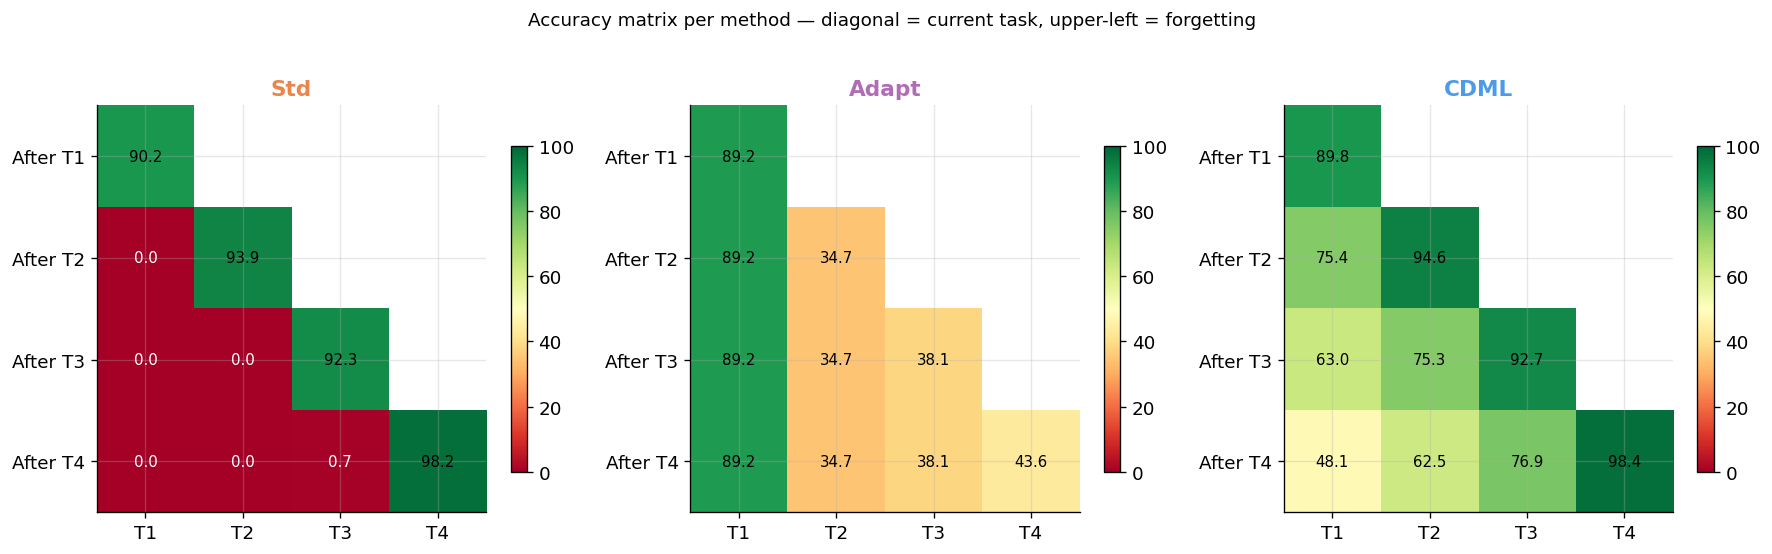

Saved: fig_accuracy_matrices.png


In [10]:
method_colors = {'Std': '#E8864C', 'Adapt': '#B06DB5', 'CDML': '#4C9BE8'}
task_colors   = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']
n_tasks       = len(task_names)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (method, acc_matrix) in zip(axes, results.items()):
    masked = np.ma.masked_invalid(acc_matrix * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(n_tasks))
    ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)])
    ax.set_yticklabels([f'After T{i+1}' for i in range(n_tasks)])
    ax.set_title(method, fontsize=13, fontweight='bold',
                 color=method_colors[method])
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(acc_matrix[i, j]):
                v = acc_matrix[i, j] * 100
                ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                        fontsize=9, color='black' if v > 30 else 'white')

fig.suptitle('Accuracy matrix per method — diagonal = current task, '
             'upper-left = forgetting', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../Plots/fig_accuracy_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: fig_accuracy_matrices.png')

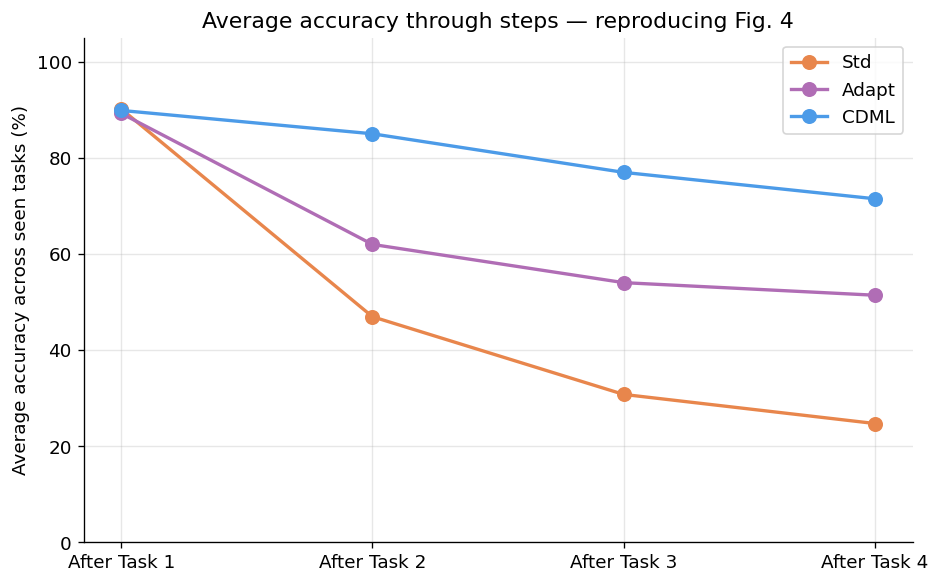

Saved: fig_avg_accuracy_steps.png

── Forgetting summary (Task 1 accuracy: initial → final) ──
  Std     : 90.2% → 0.0%  (forgetting = 90.2 pp)
  Adapt   : 89.2% → 89.2%  (forgetting = 0.0 pp)
  CDML    : 89.8% → 48.1%  (forgetting = 41.7 pp)


In [11]:
# ── Fig. 4 style: average accuracy across all tasks seen, per step ────────────
fig, ax = plt.subplots(figsize=(8, 5))

for method, acc_matrix in results.items():
    avg_accs = []
    for step in range(n_tasks):
        # Average over all tasks evaluated at this step (ignoring NaN)
        row = acc_matrix[step, :step+1]
        avg_accs.append(np.nanmean(row) * 100)
    ax.plot(range(1, n_tasks+1), avg_accs, 'o-',
            color=method_colors[method], linewidth=2, markersize=8,
            label=method)

ax.set_xticks(range(1, n_tasks+1))
ax.set_xticklabels([f'After Task {i}' for i in range(1, n_tasks+1)])
ax.set_ylabel('Average accuracy across seen tasks (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.set_title('Average accuracy through steps — reproducing Fig. 4')
plt.tight_layout()
plt.savefig('../Plots/fig_avg_accuracy_steps.png', bbox_inches='tight')
plt.show()
print('Saved: fig_avg_accuracy_steps.png')

# ── Numeric forgetting summary ────────────────────────────────────────────────
print('\n── Forgetting summary (Task 1 accuracy: initial → final) ──')
for method, acc_matrix in results.items():
    init = acc_matrix[0, 0] * 100
    final= acc_matrix[-1, 0] * 100
    print(f'  {method:<8}: {init:.1f}% → {final:.1f}%  '
          f'(forgetting = {init - final:.1f} pp)')

## 7. CDML: visualize the modulation effect on the embedding space

This reproduces the t-SNE projection in Fig. 3 of the paper, showing that CDML
achieves a more uniform distribution of task representations in the feature space.

In [12]:
from sklearn.manifold import TSNE

@torch.no_grad()
def extract_embeddings(model, task_data, task_names, device, max_per_task=200):
    """
    Extract feature embeddings h from the model for all tasks.
    For CDML models, uses the correct sequence per task.
    Returns embeddings array and task label array for t-SNE.
    """
    model.eval()
    all_embeds, all_task_labels = [], []

    for task_idx, task_name in enumerate(task_names):
        # Restore task-specific state
        if hasattr(model, 'load_film'):
            model.load_film(task_name)
        if hasattr(model, 'set_task_sequence') and task_name in model.seeds:
            model.set_task_sequence(task_name, model.seeds[task_name])

        loader = DataLoader(task_data[task_name]['test'],
                            batch_size=64, shuffle=False)
        embeds = []
        for X_b, _ in loader:
            X_b = X_b.to(device)
            # Get h (post-CDML/FiLM if applicable)
            if hasattr(model, 'backbone'):
                h = model.backbone.embed(X_b)
                if hasattr(model, 'film'):
                    h = model.film(h)
                elif hasattr(model, 'cdml'):
                    h = model.cdml(h)
            else:
                h = model.embed(X_b)
            embeds.append(h.cpu().numpy())

        embeds = np.concatenate(embeds, axis=0)[:max_per_task]
        all_embeds.append(embeds)
        all_task_labels.extend([task_idx] * len(embeds))

    return np.concatenate(all_embeds, axis=0), np.array(all_task_labels)


# Extract embeddings for each method
tsne_results = {}
for method, model in [('Std', model_std), ('Adapt', model_adapt), ('CDML', model_cdml)]:
    embeds, task_labels = extract_embeddings(model, task_data, task_names, DEVICE)
    tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, n_iter=500)
    tsne_results[method] = (tsne.fit_transform(embeds), task_labels)
    print(f'{method}: t-SNE complete on {len(embeds)} embeddings')

Std: t-SNE complete on 800 embeddings
Adapt: t-SNE complete on 800 embeddings
CDML: t-SNE complete on 800 embeddings


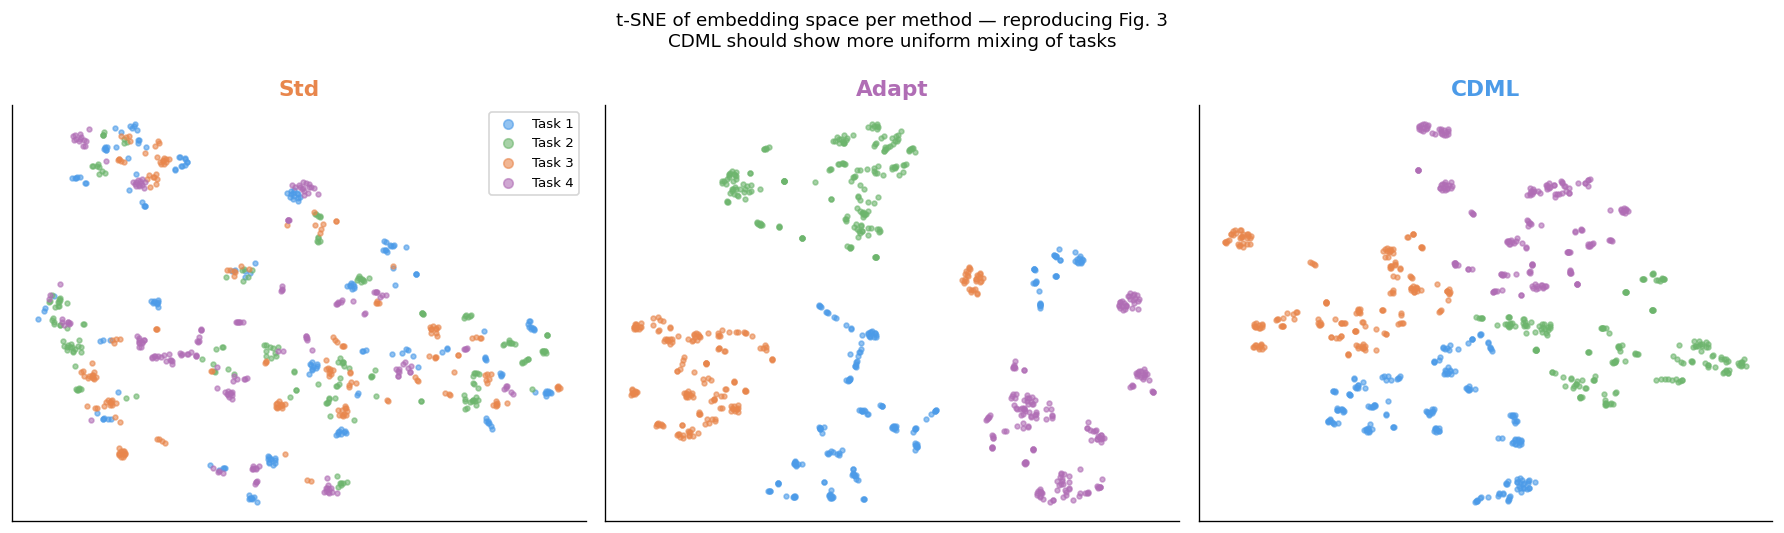

Saved: fig_tsne_embeddings.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
task_palette = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

for ax, (method, (proj, task_labels)) in zip(axes, tsne_results.items()):
    for task_idx in range(n_tasks):
        mask = task_labels == task_idx
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=task_palette[task_idx], s=8, alpha=0.6,
                   label=f'Task {task_idx+1}')
    ax.set_title(method, fontsize=13, fontweight='bold',
                 color=method_colors[method])
    ax.set_xticks([])
    ax.set_yticks([])
    if method == 'Std':
        ax.legend(fontsize=8, markerscale=2)

fig.suptitle('t-SNE of embedding space per method — reproducing Fig. 3\n'
             'CDML should show more uniform mixing of tasks', fontsize=11)
plt.tight_layout()
plt.savefig('../Plots/fig_tsne_embeddings.png', bbox_inches='tight')
plt.show()
print('Saved: fig_tsne_embeddings.png')

## 8. Ablation: effect of replay fraction on accuracy

Reproduces the ablation study from the paper (Fig. 4, multiple replay %):  
run CDML with 0%, 10%, and 30% replay and compare average accuracy.

In [14]:
# NOTE: This cell takes 3× the time of a single run. Comment out
# individual fractions to save time during development.

ablation_results = {}

for frac in REPLAY_FRACTIONS:
    label = f'CDML + replay {int(frac*100)}%'
    print(f'\n=== Ablation: {label} ===')
    m = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                     seed=CDML_SEED_BASE).to(DEVICE)
    acc_mat, _ = run_sequential_training(
        m, task_data, task_names, label,
        EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, DEVICE,
        replay_fraction=frac
    )
    ablation_results[label] = acc_mat

print('\nAblation complete.')


=== Ablation: CDML + replay 0% ===

----------------------------------------------------
[CDML + replay 0%] Step 1: Task 1
----------------------------------------------------
  CDML sequence seed: 1000
  Epoch   1/50  train 0.665  val 0.925  lr 9.80e-04
  Epoch  10/50  train 0.998  val 0.985  lr 8.17e-04
  Epoch  20/50  train 1.000  val 0.987  lr 6.68e-04
  Epoch  30/50  train 1.000  val 0.989  lr 5.45e-04
  Epoch  40/50  train 1.000  val 0.989  lr 4.46e-04
  Epoch  50/50  train 1.000  val 0.988  lr 3.64e-04

  Evaluation after Task 1:
    Task 1: 89.9%

----------------------------------------------------
[CDML + replay 0%] Step 2: Task 2
----------------------------------------------------
  CDML sequence seed: 1001
  Epoch   1/50  train 0.857  val 0.945  lr 9.80e-04
  Epoch  10/50  train 0.991  val 0.980  lr 8.17e-04
  Epoch  20/50  train 1.000  val 0.985  lr 6.68e-04
  Epoch  30/50  train 1.000  val 0.990  lr 5.45e-04
  Epoch  40/50  train 1.000  val 0.991  lr 4.46e-04
  Epoch  5

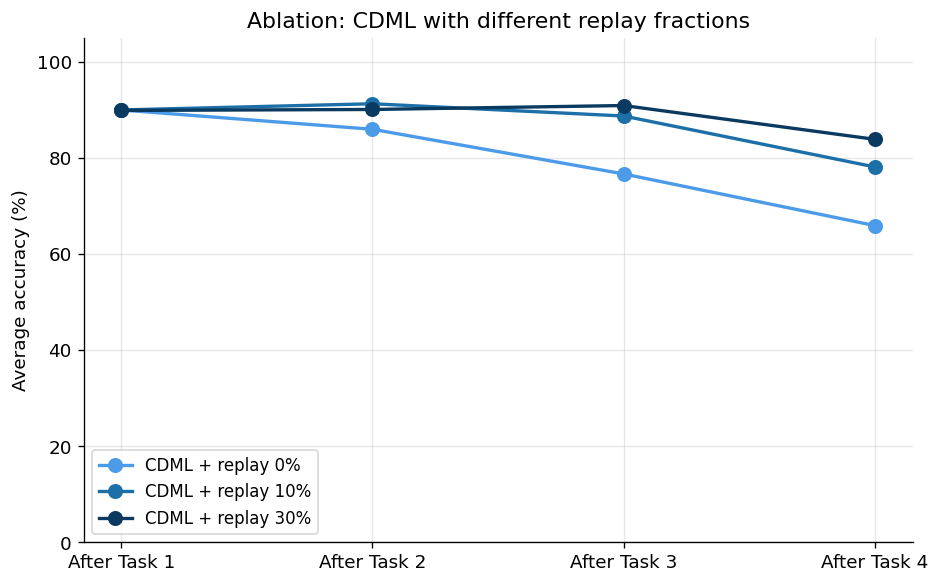

Saved: fig_ablation_replay.png


In [15]:
# ── Plot ablation results ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ablation_colors = ['#4C9BE8', '#1D6FA8', '#0A3A60']

for (label, acc_matrix), color in zip(ablation_results.items(), ablation_colors):
    avg_accs = [np.nanmean(acc_matrix[step, :step+1]) * 100
                for step in range(n_tasks)]
    ax.plot(range(1, n_tasks+1), avg_accs, 'o-',
            color=color, linewidth=2, markersize=8, label=label)

ax.set_xticks(range(1, n_tasks+1))
ax.set_xticklabels([f'After Task {i}' for i in range(1, n_tasks+1)])
ax.set_ylabel('Average accuracy (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.set_title('Ablation: CDML with different replay fractions')
plt.tight_layout()
plt.savefig('../Plots/fig_ablation_replay.png', bbox_inches='tight')
plt.show()
print('Saved: fig_ablation_replay.png')

## 9. Save all checkpoints

In [16]:
torch.save({
    'model_std':         model_std.state_dict(),
    'model_adapt':       model_adapt.state_dict(),
    'model_cdml':        model_cdml.state_dict(),
    'cdml_seeds':        model_cdml.seeds,
    'adapt_film_states': model_adapt.film_states,
    'results':           results,
    'histories':         histories,
    'ablation_results':  ablation_results,
    'config': {
        'n_channels': N_CHANNELS, 'n_classes': N_CLASSES_TOTAL,
        'embed_dim':  EMBED_DIM,  'epochs':    EPOCHS,
        'lr_init':    LR_INIT,    'lr_decay':  LR_DECAY,
        'task_splits': TASK_SPLITS,
    },
}, 'checkpoint_phase3.pt')
print('Saved: checkpoint_phase3.pt')

Saved: checkpoint_phase3.pt


## 10. Summary and next steps

### What we implemented

| Class | Description |
|---|---|
| `GaitCNN` | Shared backbone — 4× ConvBlock → FC embed → FC classify |
| `FiLMLayer` | Learnable γ, β per task. `m = γₖ * h + βₖ` |
| `GaitCNN_Adapt` | Backbone + FiLM. Saves/restores per-task FiLM states |
| `CDMLLayer` | Binary sequence buffer `sₖ`. `m = sₖ ⊙ h` |
| `GaitCNN_CDML` | Backbone + CDML. Switches sequence per task via seed |
| `run_sequential_training` | Unified loop for all methods + replay support |

### What to check in results

- **Accuracy matrices**: CDML diagonal should be comparable to Std, but off-diagonal (forgetting) should be smaller
- **Fig. 4 reproduction**: CDML average accuracy curve should sit above Std and close to Adapt
- **t-SNE (Fig. 3)**: CDML embedding space should look more uniformly mixed than Std
- **Ablation**: Adding 10% replay to CDML should push accuracy slightly higher with minimal cost

### Next steps — Phase 4

- [ ] Implement the **LiRA membership inference attack** (likelihood thresholding)
- [ ] Compute **AUC and EER** for each method → reproduce Table III
- [ ] Show that CDML brings AUC ≈ 50% (random guess) — the attacker gains nothing
- [ ] Explore stronger attacks (gradient-based, shadow models) as your novel contribution

---
*Notebook: phase3_cdml.ipynb*